<a href="https://colab.research.google.com/github/DilakshanRahul12/CM2604/blob/Final/ML_2330942_20231421.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [303]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [304]:
from google.colab import drive
drive.mount('/content/drive')
dataset = '/content/drive/MyDrive/CM2604/dataset/bank-additional/bank-additional-full.csv'
df = pd.read_csv(dataset, sep=';')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## EDA

### General Info

In [305]:
df.shape

(41188, 21)

In [306]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [307]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [308]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [309]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


no null

#### data value count

In [310]:
for col in df.columns:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print("\n")

--- age ---
age
31    1947
32    1846
33    1833
36    1780
35    1759
      ... 
89       2
91       2
94       1
87       1
95       1
Name: count, Length: 78, dtype: int64


--- job ---
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64


--- marital ---
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64


--- education ---
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64


--- default ---
default
no         32588
unknown     8597
yes            3
Name: count, dty

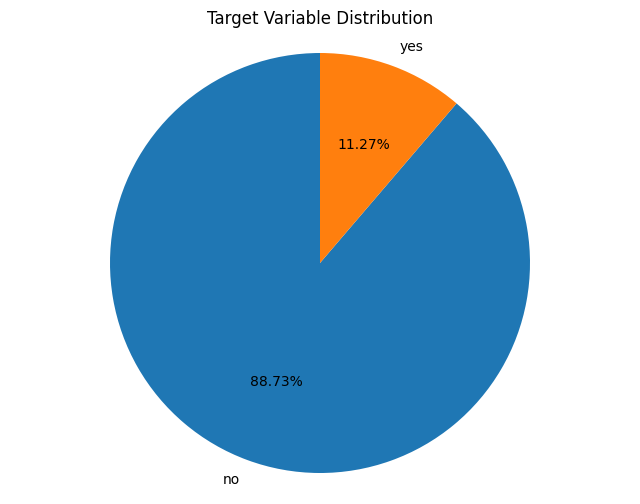

y
no     36548
yes     4640
Name: count, dtype: int64


In [311]:
y_counts = df['y'].value_counts()
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
plt.pie(y_counts, labels=y_counts.index, autopct='%.2f%%', startangle=90)
plt.title('Target Variable Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()
print(y_counts)

### Numeric

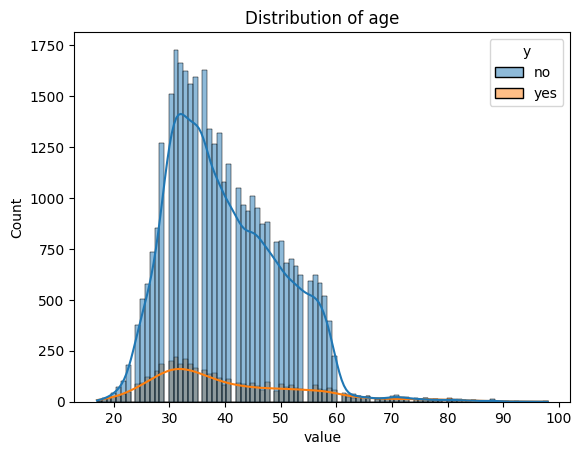

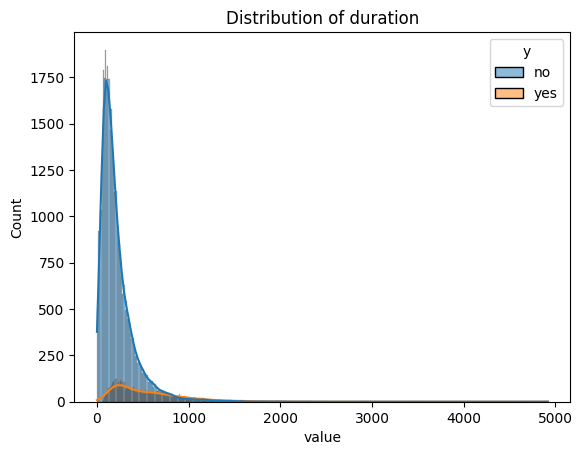

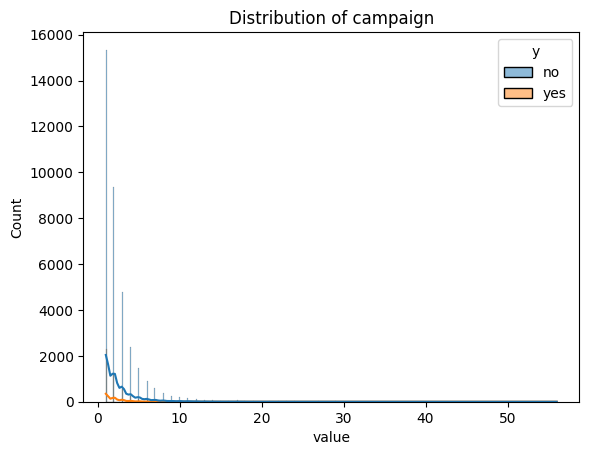

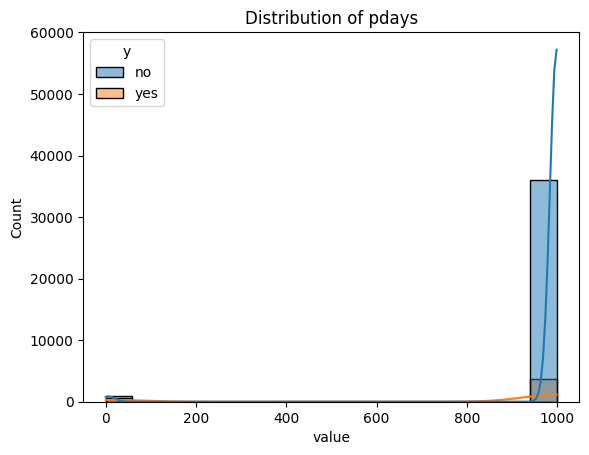

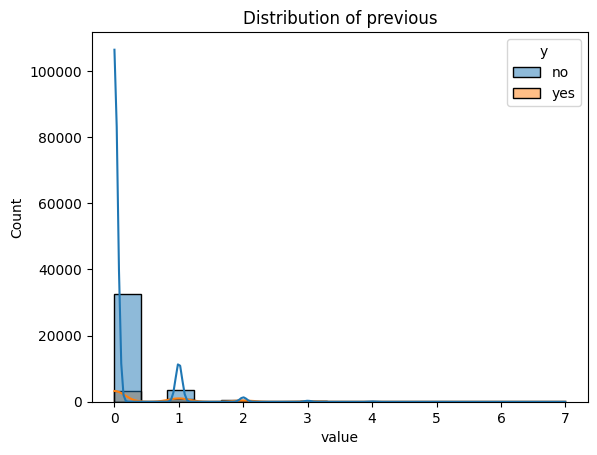

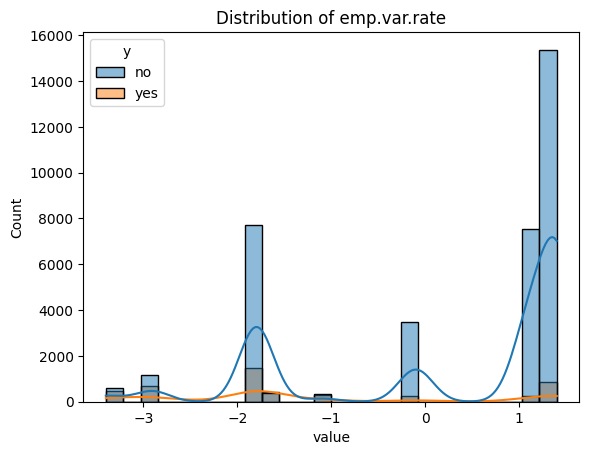

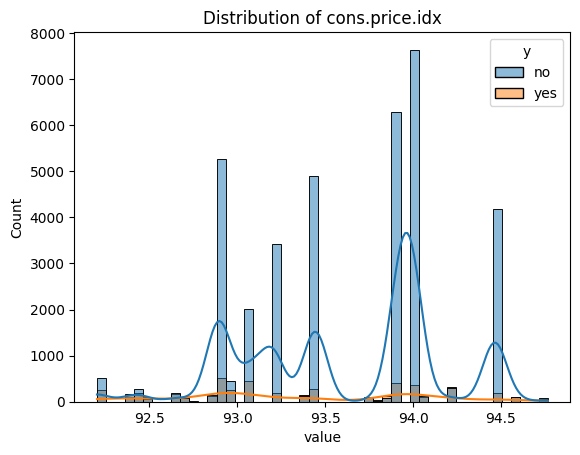

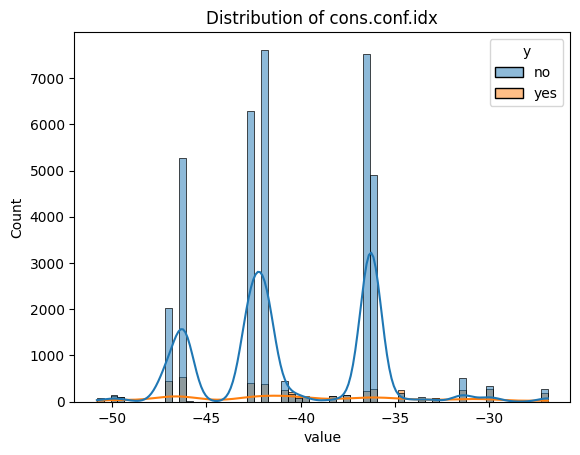

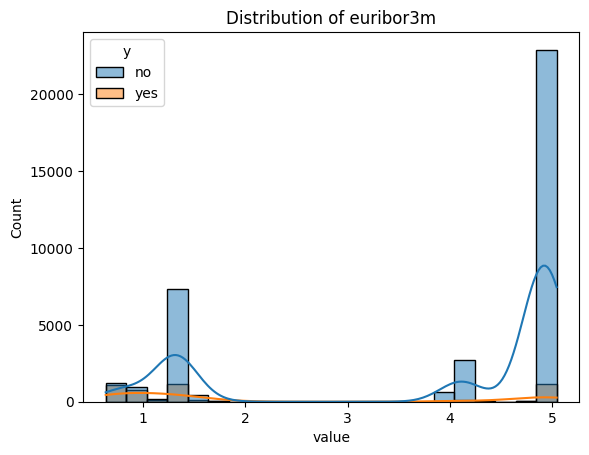

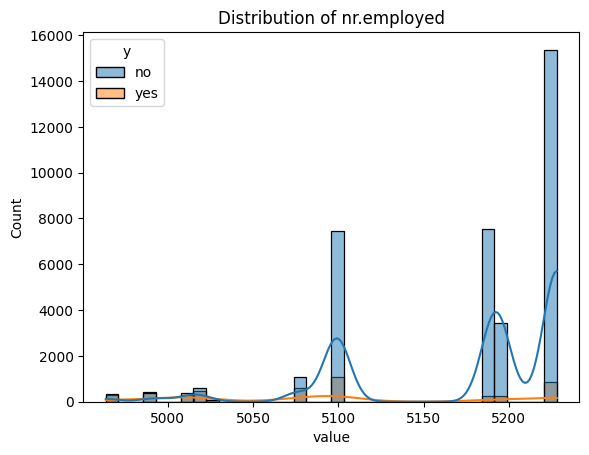

In [312]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    # Melt the dataframe to convert it to long-form
    df_melted = pd.melt(df, id_vars=['y'], value_vars=[col])  # 'y' is the hue column

    # Now use the melted dataframe for histplot
    sns.histplot(data=df_melted, x='value', hue='y', kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

#### <font color = "gold">Observations</font>

***con.price.idx ~ Comb Distribution***

### Categorial

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64


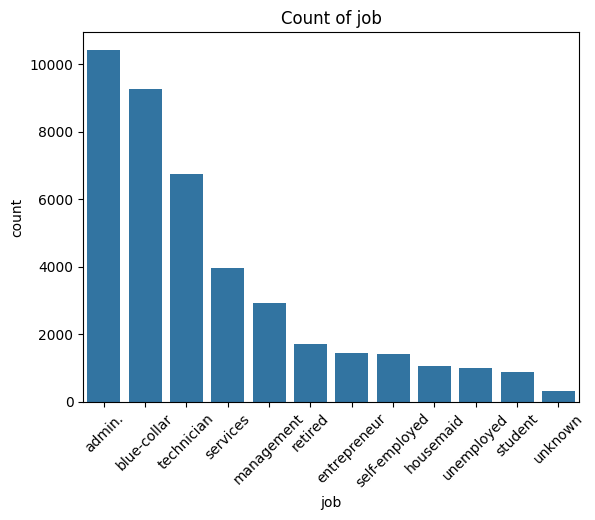

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64


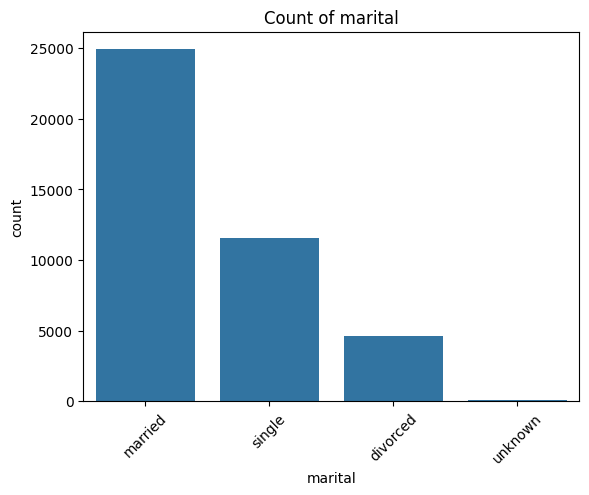

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64


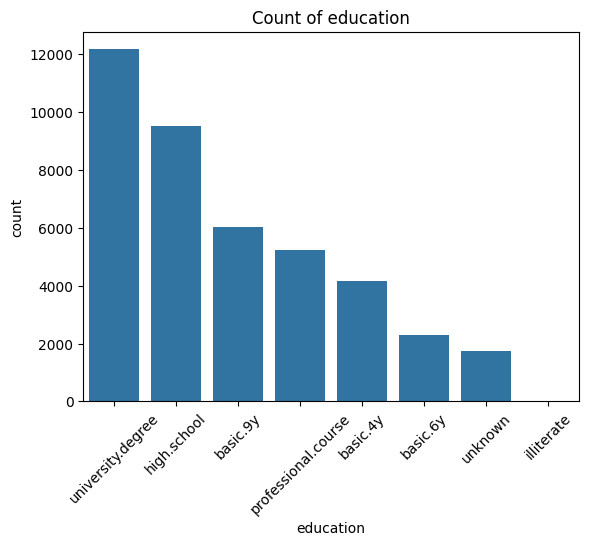

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64


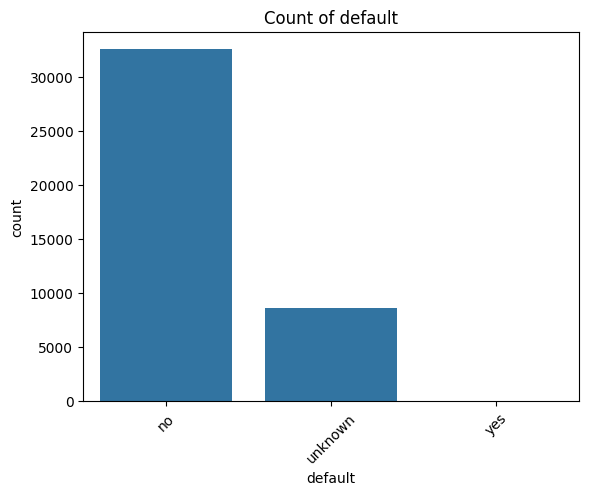

housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64


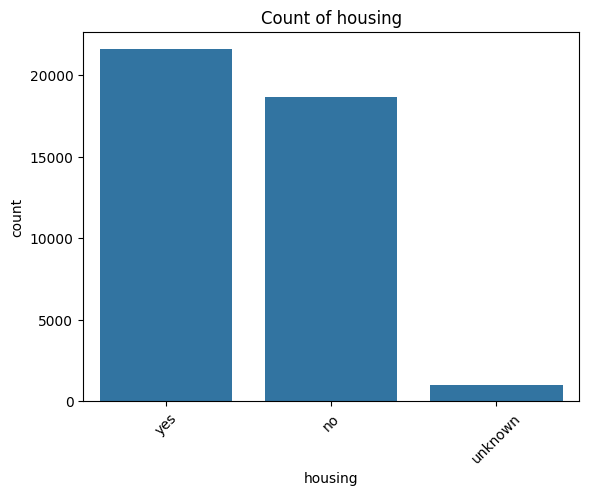

loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64


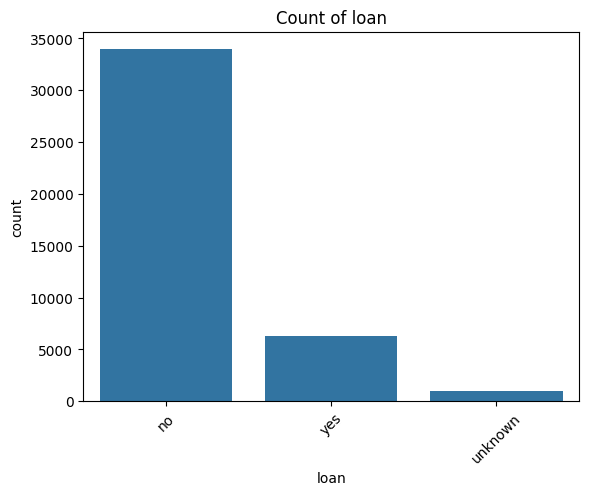

contact
cellular     26144
telephone    15044
Name: count, dtype: int64


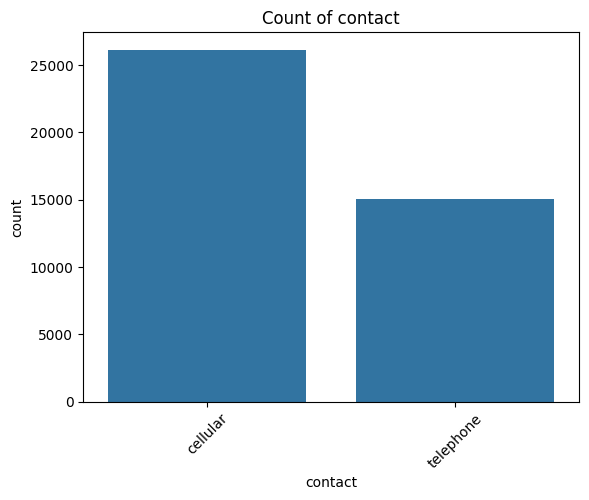

month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182
Name: count, dtype: int64


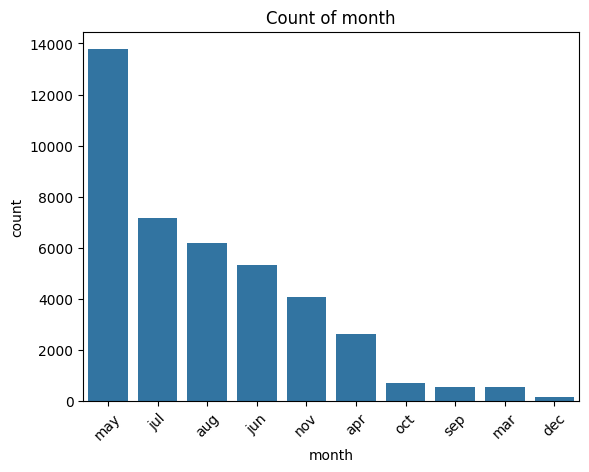

day_of_week
thu    8623
mon    8514
wed    8134
tue    8090
fri    7827
Name: count, dtype: int64


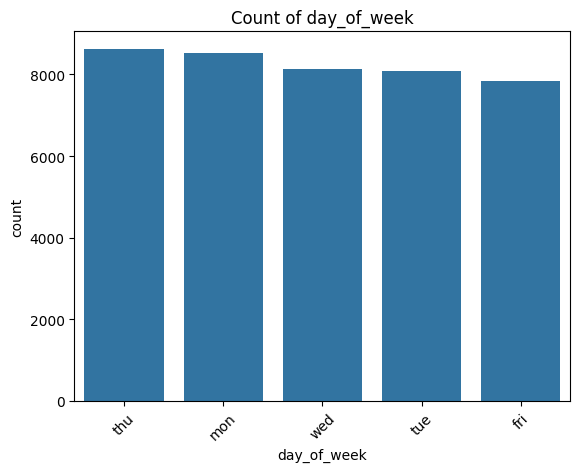

poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64


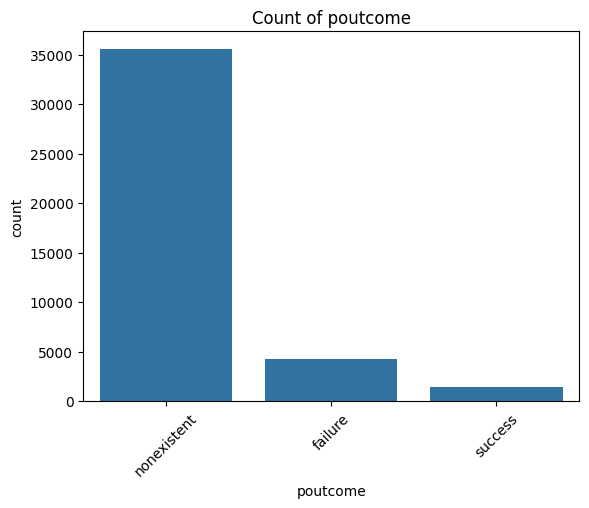

y
no     36548
yes     4640
Name: count, dtype: int64


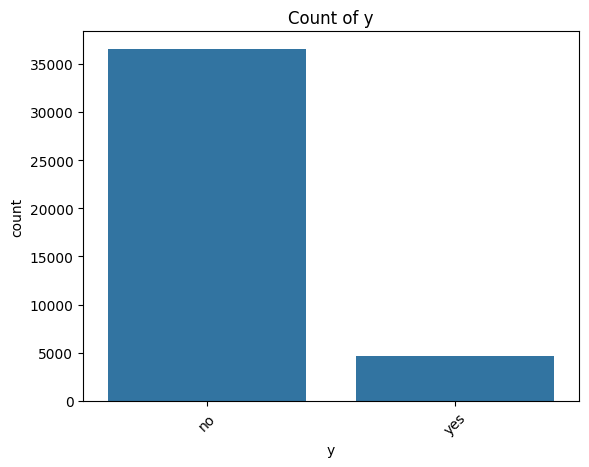

In [313]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(df[col].value_counts())
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.show()

### Numerical vs. Target

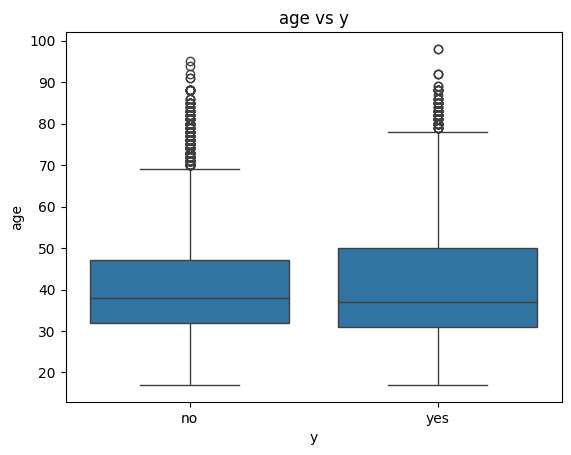

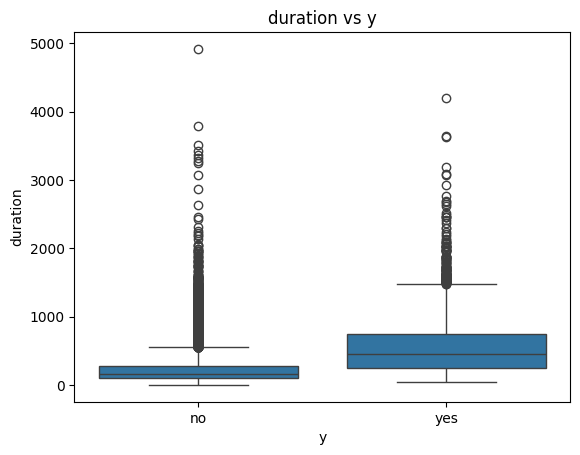

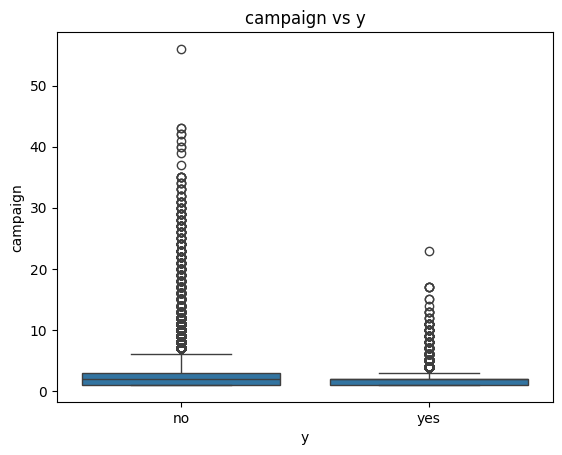

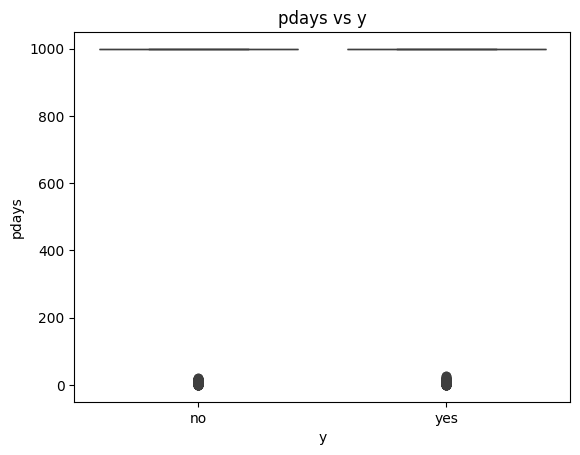

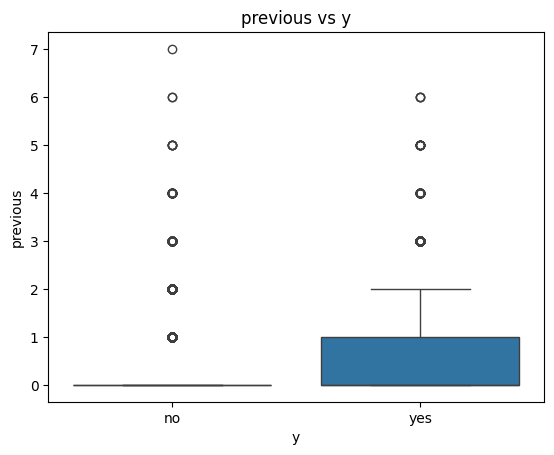

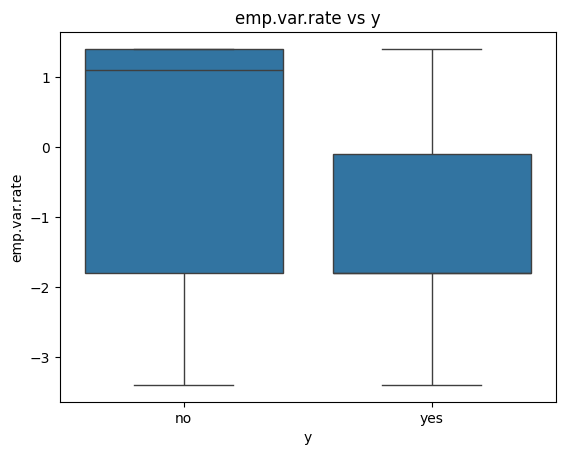

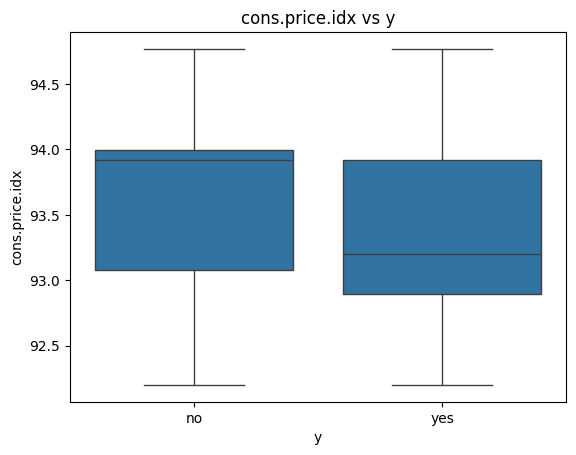

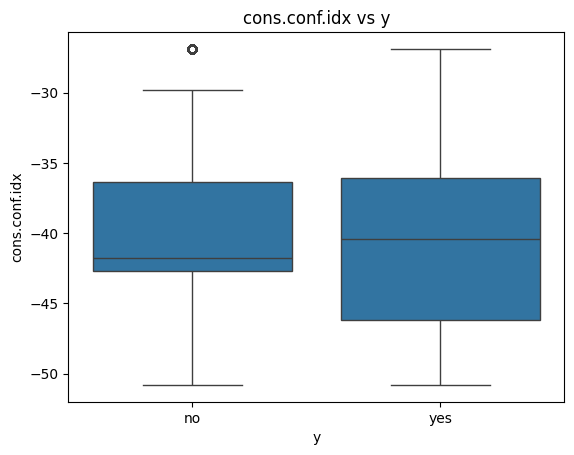

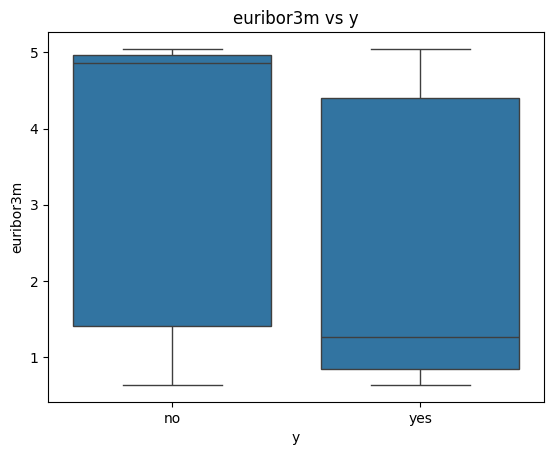

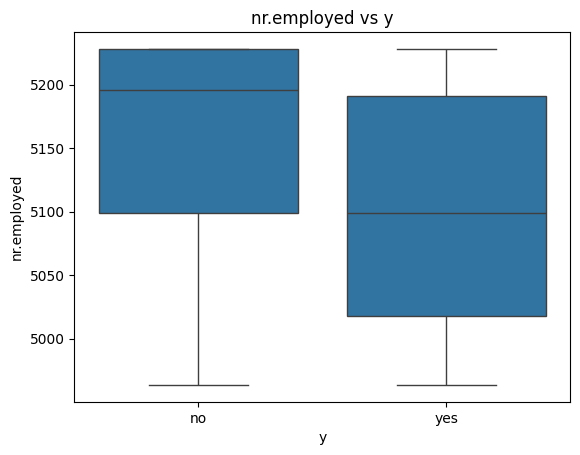

In [314]:
for col in numeric_cols:
    sns.boxplot(x='y', y=col, data=df)
    plt.title(f'{col} vs y')
    plt.show()

### Categorical vs. Target

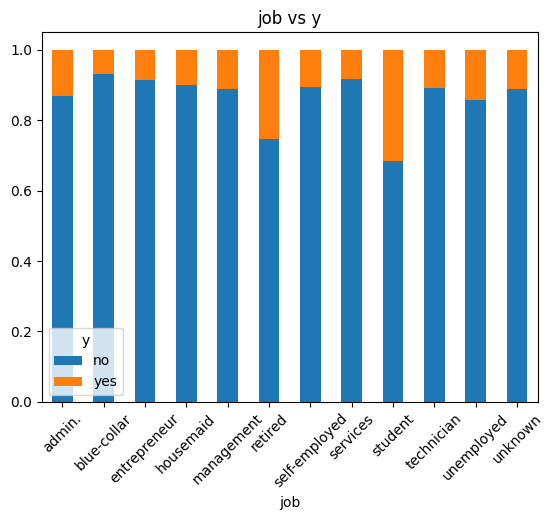

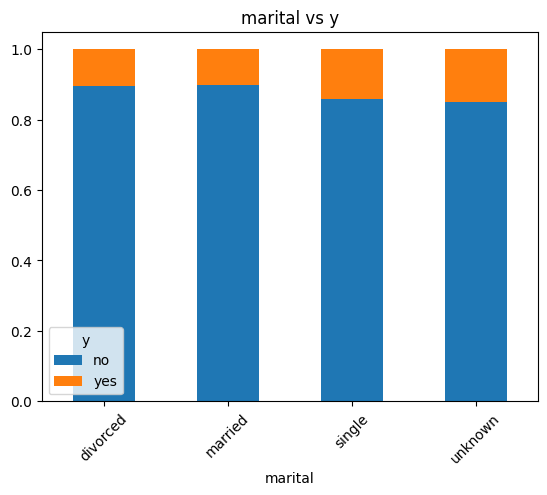

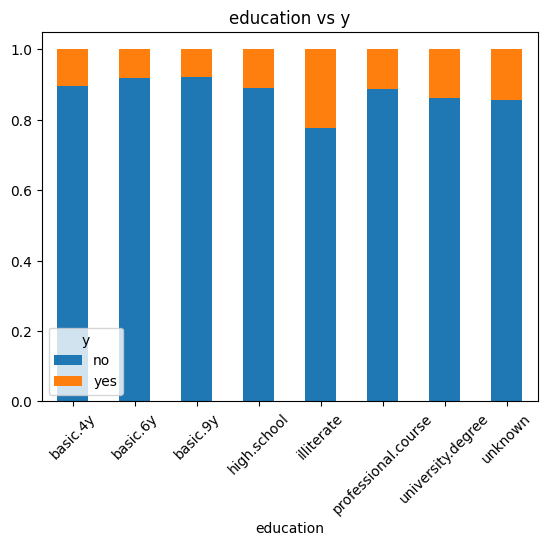

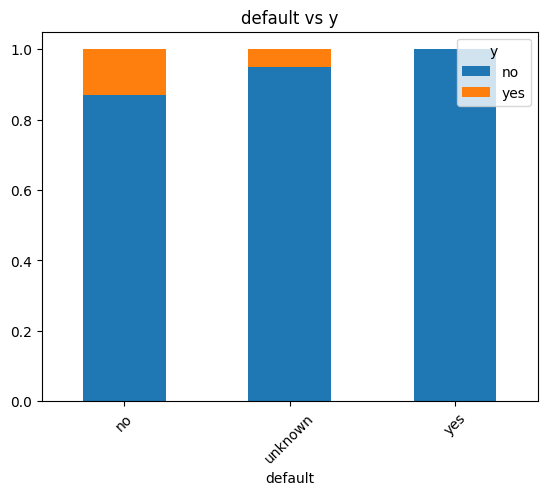

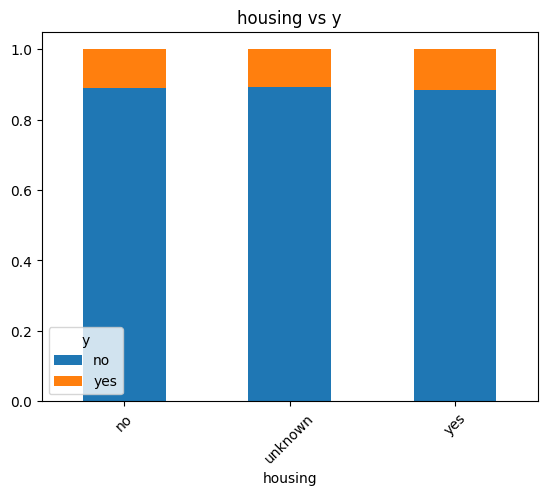

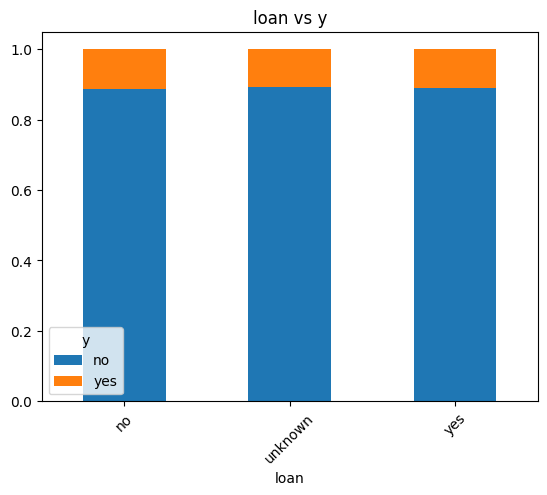

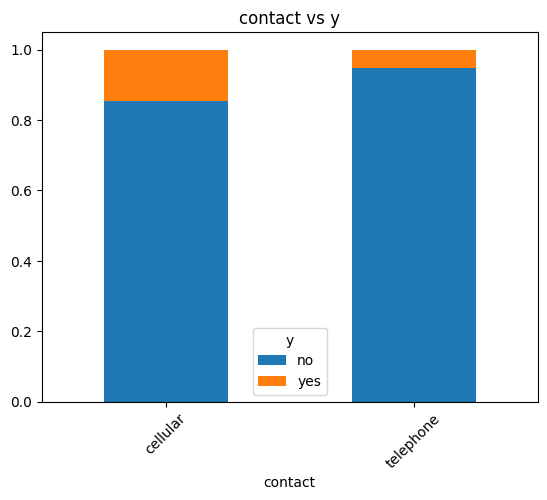

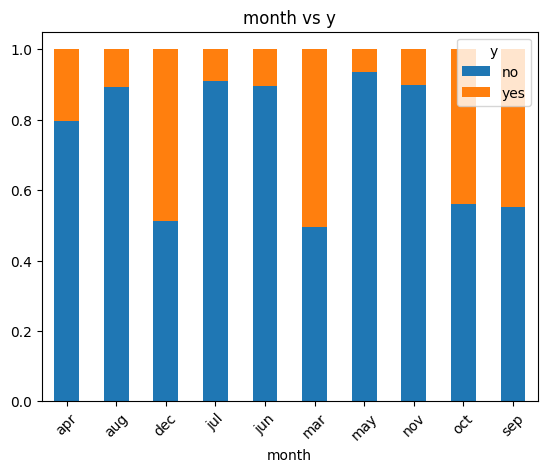

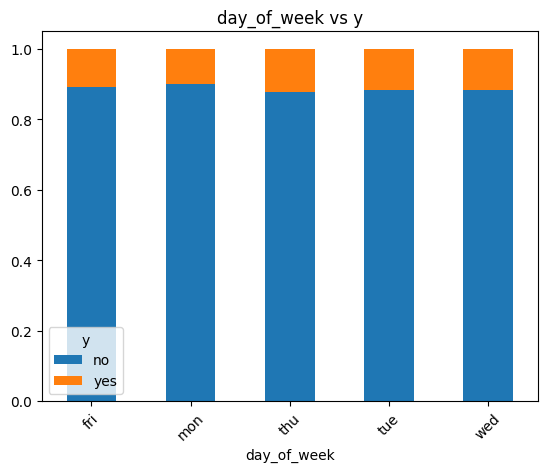

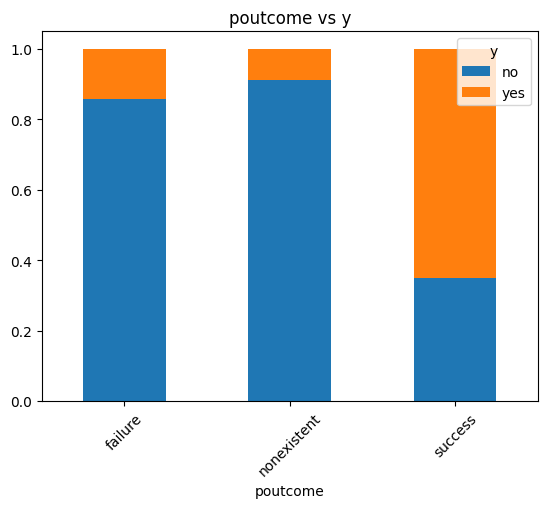

In [315]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
  if col != 'y':
    pd.crosstab(df[col], df['y'], normalize='index').plot(kind='bar', stacked=True)
    plt.title(f'{col} vs y')
    plt.xticks(rotation=45)
    plt.show()

### Duration

In [316]:
df['duration'].describe()

,duration
count,41188.000000
mean,258.285010
std,259.279249
min,0.000000
25%,102.000000
50%,180.000000
75%,319.000000
max,4918.000000


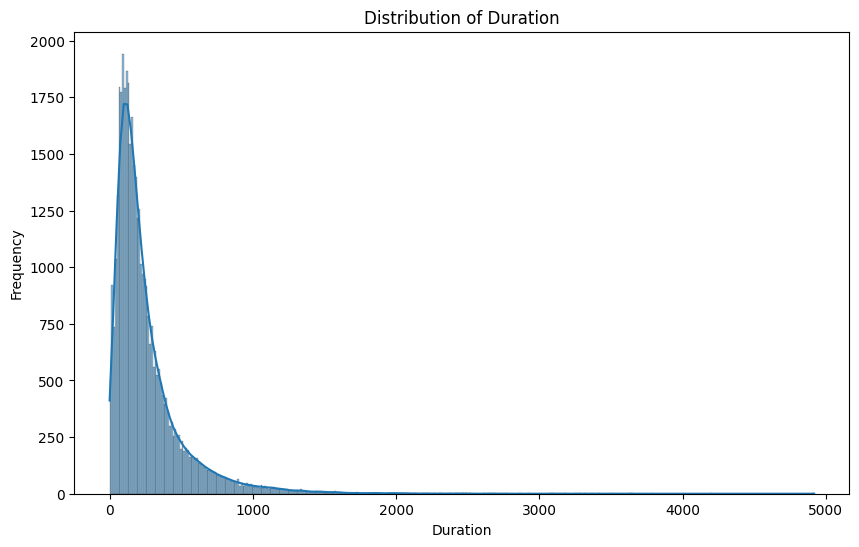

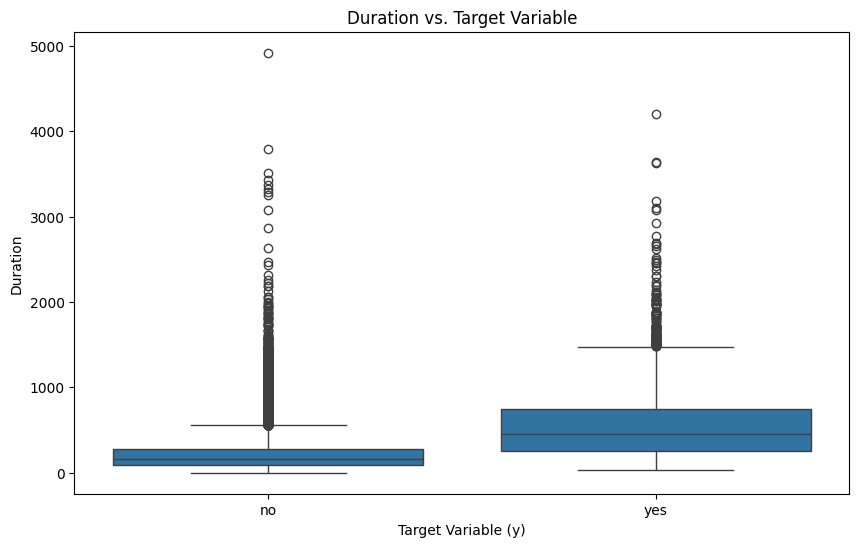

In [317]:
plt.figure(figsize=(10, 6))
sns.histplot(df['duration'], kde=True)
plt.title('Distribution of Duration')
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='y', y='duration', data=df)
plt.title('Duration vs. Target Variable')
plt.xlabel('Target Variable (y)')
plt.ylabel('Duration')
plt.show()

idea of validating duration to use it as feature rather using it has a benchmark

In [318]:
# Calculate and display the mean duration for each target value
print(df.groupby('y')['duration'].mean())

y
no     220.844807
yes    553.191164
Name: duration, dtype: float64


In [319]:
# Filter the DataFrame for 'y' equal to 'yes' and 'duration' less than 400
filtered_df_yes = df[(df['y'] == 'yes') & (df['duration'] < 221)]
filtered_df_no = df[(df['y'] == 'no') & (df['duration'] > 553)]

# Get the number of rows in the filtered DataFrame, which represents the count
count_y_yes_duration_lt_221 = len(filtered_df_yes)
count_y_no_duration_lt_553 = len(filtered_df_no)

print(f"Number of 'yes' with duration less than 221: {count_y_yes_duration_lt_221}")
print(f"Number of 'no' with duration large than 553: {count_y_no_duration_lt_553}")

Number of 'yes' with duration less than 221: 895
Number of 'no' with duration large than 553: 2194


In [320]:
# Get the number of rows in the filtered DataFrame
count_y_no_duration_gt_553 = len(filtered_df_no)

# Calculate the average duration for the filtered data
average_duration_y_no_gt_553 = filtered_df_no['duration'].mean()

print(f"Number of 'no' with duration greater than 553: {count_y_no_duration_gt_553}")
print(f"Average duration for 'no' with duration greater than 553: {average_duration_y_no_gt_553}")

Number of 'no' with duration greater than 553: 2194
Average duration for 'no' with duration greater than 553: 814.989516864175


In [321]:
filtered_df_no = df[(df['y'] == 'no') & (df['duration'] >= 814) & (df['duration'] <= df['duration'].max())]

# Get the number of rows in the filtered DataFrame
count_y_no_duration_814_max = len(filtered_df_no)

# Calculate the average duration for 'y' equal to 'no' within the specified range
average_duration_y_no = filtered_df_no['duration'].mean()

print(f"Number of 'no' with duration between 814 and max: {count_y_no_duration_814_max}")
print(f"Average duration for 'no' with duration greater than 553: {average_duration_y_no}")

filtered_df_no = df[(df['y'] == 'no') & (df['duration'] >= 1141) & (df['duration'] <= df['duration'].max())]

count_y_no_duration_1141_max = len(filtered_df_no)

print(f"Number of 'no' with duration between 1141 and max: {count_y_no_duration_1141_max}")

Number of 'no' with duration between 814 and max: 712
Average duration for 'no' with duration greater than 553: 1141.431179775281
Number of 'no' with duration between 1141 and max: 253


In [322]:
total_data_count = len(df)
result = (count_y_no_duration_gt_553 - count_y_no_duration_814_max) / total_data_count * 100
result

3.5981353792366706

There is an anonmoly, So we can include duration for more calucation

## Data Preprocessing

Handling outlier | Data cleaning | Data Transformation | Data Reduction | Data vaildation

In [362]:
#duration
df_dur = df[df['duration'] < 814].copy() #814
df_dur.shape

#age
df_dur['age'] = df_dur['age'].apply(lambda x: 66 if x > 66 else x)
#campaign
df_dur['campaign'] = np.log1p(df_dur['campaign'])

#pdays
def categorize_pdays(pdays):
    if 0 <= pdays <= 30:
        return 'recently contacted'
    elif 31 <= pdays <= 90:
        return 'contacted few months ago'
    elif 91 <= pdays <= 998:
        return 'contacted long ago'
    elif pdays == 999:
        return 'not contacted'
# Apply the function to create the new categorical feature
df_dur['pdays'] = df_dur['pdays'].apply(categorize_pdays)
#previous
df_dur['previous'] = np.log1p(df_dur['previous'])

df_handled = df_dur.copy()

df_handled['duration'] = np.log1p(df_handled['duration'])  # log(1 + x) for duration

df_encoded1 = df_handled.copy()


# --- ENCODE ---


from sklearn.preprocessing import LabelEncoder
# Initialize LabelEncoders and store mappings
label_encoders = {}
mappings = {}
# Iterate through categorical columns
for column in df_encoded1.select_dtypes(include=['object']):
    le = LabelEncoder()
    df_encoded1[column] = le.fit_transform(df_encoded1[column])
    label_encoders[column] = le
    mappings[column] = dict(zip(le.classes_, le.transform(le.classes_)))

# Display the mappings
# for column, mapping in mappings.items():
#     print(f"Mappings for column '{column}':")
#     print(mapping)
#     print("---")

df_feat = df_encoded1.copy()

In [363]:
df_feat.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,5.568345,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,5.010635,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,5.424950,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,5.023881,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,5.730100,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0


For Random Forest

In [325]:
df_dt_rf = df_feat.copy()

For ANN

In [326]:
df_dt_ann = df_feat.copy()

In [327]:
df_dt_ann.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,5.568345,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,5.010635,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,5.424950,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,5.023881,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,5.730100,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0


In [328]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

correlated_features = ['emp.var.rate', 'euribor3m', 'nr.employed', 'cons.price.idx']
# Standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_dt_ann[correlated_features])

pca = PCA(n_components=1)
pca_component = pca.fit_transform(scaled_features)
#PCA component to the dataframe and drop original features
df_dt_ann['econ.idx'] = pca_component
df_dt_ann.drop(columns=correlated_features, inplace=True)


# Combine pdays and previous
df_dt_ann['pdays_previous_ratio'] = df_dt_ann['pdays'] / (df_dt_ann['previous'] + 1)  # Avoid division by zero

Data standardization

In [329]:
features_to_scale = df_dt_ann.drop('y', axis=1).columns
scaler = StandardScaler()
df_dt_ann[features_to_scale] = scaler.fit_transform(df_dt_ann[features_to_scale])

In [330]:
df_dt_ann.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,cons.conf.idx,y,econ.idx,pdays_previous_ratio
0,1.607096,-0.202991,-0.28187,-1.753954,-0.513501,-1.088374,-0.451735,1.314745,0.761512,-0.717842,0.557129,-0.862359,-0.194432,-0.38202,0.19554,0.883595,0,0.648961,-0.192473
1,1.706958,0.908786,-0.28187,-0.350203,1.945627,-1.088374,-0.451735,1.314745,0.761512,-0.717842,-0.098732,-0.862359,-0.194432,-0.38202,0.19554,0.883595,0,0.648961,-0.192473
2,-0.290287,0.908786,-0.28187,-0.350203,-0.513501,0.941613,-0.451735,1.314745,0.761512,-0.717842,0.388498,-0.862359,-0.194432,-0.38202,0.19554,0.883595,0,0.648961,-0.192473
3,0.009300,-1.036825,-0.28187,-1.286037,-0.513501,-1.088374,-0.451735,1.314745,0.761512,-0.717842,-0.083155,-0.862359,-0.194432,-0.38202,0.19554,0.883595,0,0.648961,-0.192473
4,1.607096,0.908786,-0.28187,-0.350203,-0.513501,-1.088374,2.315841,1.314745,0.761512,-0.717842,0.747351,-0.862359,-0.194432,-0.38202,0.19554,0.883595,0,0.648961,-0.192473


## Models

### RF

In [331]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Assuming df_dt is your preprocessed DataFrame and 'y' is your target variable column
X = df_dt_rf.drop('y', axis=1)
y = df_dt_rf['y']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

#### RF1 (normal)

In [332]:
rf1 = RandomForestClassifier()
rf1.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf1.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9296291608657132
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      7178
           1       0.66      0.47      0.55       723

    accuracy                           0.93      7901
   macro avg       0.81      0.72      0.76      7901
weighted avg       0.92      0.93      0.92      7901



#### RF2 (OverSampling)

In [333]:
from imblearn.over_sampling import RandomOverSampler

oversampler = RandomOverSampler(random_state=11,sampling_strategy='minority')
X_resampled, y_resampled = oversampler.fit_resample(X_train, y_train)

from sklearn.ensemble import RandomForestClassifier

# Initialize and train a RandomForestClassifier
rf2 = RandomForestClassifier(n_estimators=100, random_state=11)  # Adjust n_estimators as needed
rf2.fit(X_resampled, y_resampled)

# Make predictions and evaluate the model
y_pred_rf = rf2.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest Classifier: {accuracy_rf}")

print(classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Accuracy of Random Forest Classifier: 0.926465004429819
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      7178
           1       0.60      0.59      0.60       723

    accuracy                           0.93      7901
   macro avg       0.78      0.78      0.78      7901
weighted avg       0.93      0.93      0.93      7901



#### RF3 (Undersampling)

In [334]:
from imblearn.under_sampling import RandomUnderSampler

X_resampled, y_resampled = RandomUnderSampler(random_state=11,sampling_strategy='not minority').fit_resample(X_train, y_train)

# Initialize and train a RandomForestClassifier (or your preferred model)
rf3 = RandomForestClassifier(n_estimators=100, random_state=11)
rf3.fit(X_resampled, y_resampled)

# Make predictions and evaluate the model
y_pred_rf = rf3.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest Classifier (Undersampled): {accuracy_rf}")

print(classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Accuracy of Random Forest Classifier (Undersampled): 0.8593848879888621
              precision    recall  f1-score   support

           0       0.99      0.85      0.92      7178
           1       0.39      0.93      0.55       723

    accuracy                           0.86      7901
   macro avg       0.69      0.89      0.73      7901
weighted avg       0.94      0.86      0.88      7901



#### RF4 (SMOTE)

In [335]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data
smote = SMOTE(random_state=42) # Added random_state for reproducibility
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Initialize and train a RandomForestClassifier
rf4 = RandomForestClassifier(n_estimators=100, random_state=11)
rf4.fit(X_train_resampled, y_train_resampled)

# Make predictions and evaluate the model
y_pred_rf = rf4.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest Classifier (SMOTE): {accuracy_rf}")

print(classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Accuracy of Random Forest Classifier (SMOTE): 0.9174788001518795
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      7178
           1       0.54      0.64      0.59       723

    accuracy                           0.92      7901
   macro avg       0.75      0.79      0.77      7901
weighted avg       0.92      0.92      0.92      7901



#### RF5 (Hyperparameterized)

In [336]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the RandomForestClassifier with the best hyperparameters
rf5 = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=2,
    max_depth=30,
    random_state=11
    )

# Train the model on the training data
rf5.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf5.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.9324136185293
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      7178
           1       0.68      0.49      0.57       723

    accuracy                           0.93      7901
   macro avg       0.82      0.73      0.77      7901
weighted avg       0.93      0.93      0.93      7901



### ANN MODELS

In [337]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
from tensorflow.keras.optimizers import Adam

In [338]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Assuming df_dt is your preprocessed DataFrame and 'y' is your target variable column
X = df_dt_ann.drop('y', axis=1)
y = df_dt_ann['y']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=11)

# Apply SMOTE to the training data
smote = SMOTE(random_state=11,sampling_strategy='minority')
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# After applying SMOTE
X_train_resampled, X_val, y_train_resampled, y_val = train_test_split(
    X_train_resampled, y_train_resampled, test_size=0.1, random_state=11
)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


#### ANN1 (SMOTE/Normal)

In [339]:
from tensorflow.keras.callbacks import EarlyStopping

# Build and compile the model
def ANN1(activation):
    model = Sequential([
        Dense(64, activation=activation, input_dim=X_train_resampled.shape[1]),
        Dropout(0.3),
        Dense(64, activation=activation),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[AUC(name='AUC')])
    return model

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
relu1 = ANN1('relu')
history_relu = relu1.fit(
    X_train_resampled, y_train_resampled,
    validation_data=(X_val, y_val),
    epochs=10, batch_size=32, verbose=1,
    callbacks=[early_stop]
)

y_probs = relu1.predict(X_test)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1511/1511 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - AUC: 0.8859 - loss: 0.4117 - val_AUC: 0.9451 - val_loss: 0.2874
Epoch 2/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.9352 - loss: 0.3076 - val_AUC: 0.9497 - val_loss: 0.2681
Epoch 3/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.9392 - loss: 0.2940 - val_AUC: 0.9525 - val_loss: 0.2581
Epoch 4/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - AUC: 0.9444 - loss: 0.2801 - val_AUC: 0.9573 - val_loss: 0.2463
Epoch 5/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - AUC: 0.9472 - loss: 0.2710 - val_AUC: 0.9605 - val_loss: 0.2380
Epoch 6/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - AUC: 0.9509 - loss: 0.2616 - val_AUC: 0.9606 - val_loss: 0.2336
Epoch 7/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - AUC: 0.9524 - loss: 0.2565 - val_AUC: 0.9620 - val_loss: 0.2287
Epoch 8/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - AUC: 0.9531 - loss: 0.2522 - val_AUC: 0.9624 - val_loss: 0.2272
Epoch 9/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/st

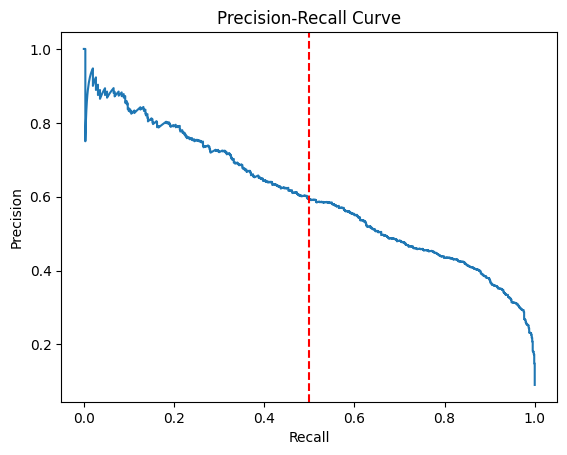

In [340]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Plot Precision-Recall Curve
plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.axvline(x=0.5, color='red', linestyle='--', label='x = 0.5')
plt.show()

In [341]:
y_pred = (y_probs > 0.5).astype(int)
new_threshold = 0.845
y_pred_new = (y_probs >= new_threshold).astype(int)

In [342]:
# Evaluate predictions
accuracy = accuracy_score(y_test, y_pred_new)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report for threshold 0.5:")
print(classification_report(y_test, y_pred))
print("Classification Report NEW:")
print(classification_report(y_test, y_pred_new))

Accuracy: 0.9200
Classification Report for threshold 0.5:
              precision    recall  f1-score   support

           0       0.99      0.87      0.92      8983
           1       0.39      0.88      0.54       893

    accuracy                           0.87      9876
   macro avg       0.69      0.87      0.73      9876
weighted avg       0.93      0.87      0.89      9876

Classification Report NEW:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      8983
           1       0.55      0.60      0.57       893

    accuracy                           0.92      9876
   macro avg       0.76      0.78      0.77      9876
weighted avg       0.92      0.92      0.92      9876



#### ANN2

In [343]:
# Build and compile the model
def ANN2(activation):
    model = Sequential([
        Dense(128, activation=activation, input_dim=X_train.shape[1]),
        Dropout(0.2),
        Dense(128, activation=activation),
        Dropout(0),
        Dense(1, activation='sigmoid')  # Binary classification
    ])

    opt = Adam(learning_rate=0.001)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['AUC'])
    return model

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train with ReLU activation function
relu2 = ANN2('relu')
history_relu = relu2.fit(
    X_train_resampled, y_train_resampled,
    validation_data=(X_val, y_val),
    epochs=10, batch_size=32, verbose=1,
    callbacks=[early_stop]
)

# Predict probabilities on the test set
y_pred_prob = relu2.predict(X_test)

# Convert probabilities to binary predictions
y_pred = (y_pred_prob > 0.88).astype(int)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1511/1511 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - AUC: 0.9159 - loss: 0.3584 - val_AUC: 0.9520 - val_loss: 0.2619
Epoch 2/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.9448 - loss: 0.2795 - val_AUC: 0.9588 - val_loss: 0.2397
Epoch 3/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.9538 - loss: 0.2508 - val_AUC: 0.9610 - val_loss: 0.2278
Epoch 4/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - AUC: 0.9585 - loss: 0.2377 - val_AUC: 0.9646 - val_loss: 0.2187
Epoch 5/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.9599 - loss: 0.2305 - val_AUC: 0.9657 - val_loss: 0.2126
Epoch 6/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.9634 - loss: 0.2203 - val_AUC: 0.9671 - val_loss: 0.2047
Epoch 7/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - AUC: 0.9634 - loss: 0.2182 - val_AUC: 0.9678 - val_loss: 0.2051
Epoch 8/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.9664 - loss: 0.2109 - val_AUC: 0.9695 - val_loss: 0.1976
Epoch 9/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/st

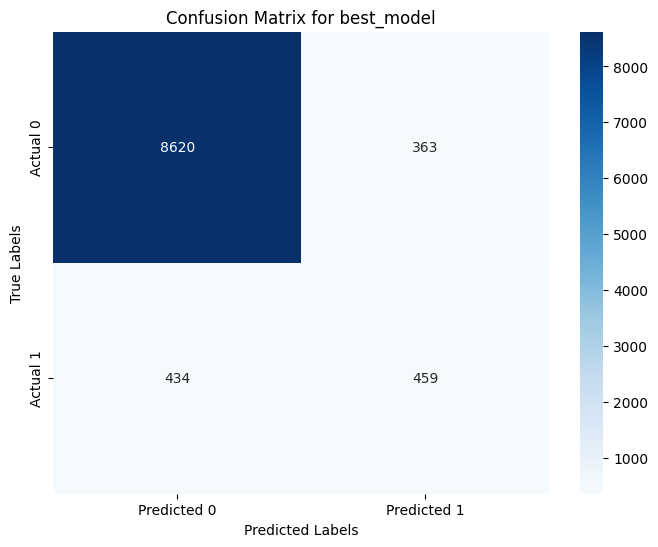


Accuracy: 0.9193


Classification Report for best_model:
              precision    recall  f1-score   support

     Class 0       0.95      0.96      0.96      8983
     Class 1       0.56      0.51      0.54       893

    accuracy                           0.92      9876
   macro avg       0.76      0.74      0.75      9876
weighted avg       0.92      0.92      0.92      9876



In [344]:
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix for best_model")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Evaluate predictions
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}\n")

# Print the classification report
print("\nClassification Report for best_model:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

### ANN3 (Small chnage in dropout)

In [345]:
def ANN3(activation='relu'):
    model = Sequential([
        Dense(128, activation=activation, input_dim=X_train.shape[1]),
        Dropout(0.2),
        Dense(128, activation=activation),
        Dropout(0.1),
        Dense(1, activation='sigmoid')  # Binary classification
    ])

    opt = Adam(learning_rate=0.001)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['AUC'])
    return model

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train with ReLU activation function
relu3 = ANN3('relu')
history_relu = relu3.fit(
    X_train_resampled, y_train_resampled,
    validation_data=(X_val, y_val),
    epochs=10, batch_size=32, verbose=1,
    callbacks=[early_stop]
)

# Predict probabilities on the test set
y_pred_prob = relu3.predict(X_test)

# Convert probabilities to binary predictions
y_pred = (y_pred_prob > 0.8).astype(int)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1511/1511 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - AUC: 0.9137 - loss: 0.3590 - val_AUC: 0.9508 - val_loss: 0.2702
Epoch 2/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - AUC: 0.9456 - loss: 0.2775 - val_AUC: 0.9604 - val_loss: 0.2394
Epoch 3/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - AUC: 0.9526 - loss: 0.2547 - val_AUC: 0.9608 - val_loss: 0.2329
Epoch 4/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - AUC: 0.9563 - loss: 0.2436 - val_AUC: 0.9659 - val_loss: 0.2180
Epoch 5/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - AUC: 0.9600 - loss: 0.2334 - val_AUC: 0.9657 - val_loss: 0.2138
Epoch 6/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - AUC: 0.9620 - loss: 0.2242 - val_AUC: 0.9678 - val_loss: 0.2094
Epoch 7/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - AUC: 0.9621 - loss: 0.2230 - val_AUC: 0.9692 - val_loss: 0.1990
Epoch 8/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - AUC: 0.9651 - loss: 0.2133 - val_AUC: 0.9690 - val_loss: 0.2008
Epoch 9/10
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/st

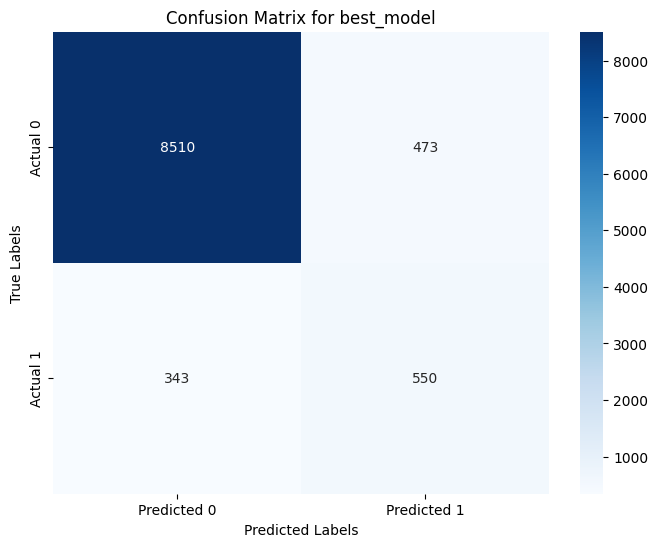


Accuracy: 0.9174


Classification Report for best_model:
              precision    recall  f1-score   support

     Class 0       0.96      0.95      0.95      8983
     Class 1       0.54      0.62      0.57       893

    accuracy                           0.92      9876
   macro avg       0.75      0.78      0.76      9876
weighted avg       0.92      0.92      0.92      9876



In [346]:
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix for best_model")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Evaluate predictions
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}\n")

# Print the classification report
print("\nClassification Report for best_model:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

#### ANN4 (undersample)

In [347]:
from imblearn.under_sampling import RandomUnderSampler

X_resampled, y_resampled = RandomUnderSampler(random_state=11,sampling_strategy='not minority').fit_resample(X_train, y_train)

X_train_resampled, X_val, y_train_resampled, y_val = train_test_split(
    X_train_resampled, y_train_resampled, test_size=0.15, random_state=11)

# Build and compile the model
def ANN4(activation):
    model = Sequential([
        Dense(128, activation=activation, input_dim=X_train.shape[1]),
        Dropout(0.2),
        Dense(128, activation=activation),
        Dropout(0),
        Dense(1, activation='sigmoid')  # Binary classification
    ])

    opt = Adam(learning_rate=0.001)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['AUC'])
    return model

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train with ReLU activation function
relu4 = ANN4('relu')
history_relu = relu4.fit(
    X_train_resampled, y_train_resampled,
    validation_data=(X_val, y_val),
    epochs=10, batch_size=32, verbose=1,
    callbacks=[early_stop]
)

# Predict probabilities on the test set
y_pred_prob = relu4.predict(X_test)

# Convert probabilities to binary predictions
y_pred = (y_pred_prob > 0.8).astype(int)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1284/1284 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - AUC: 0.9155 - loss: 0.3601 - val_AUC: 0.9428 - val_loss: 0.2855
Epoch 2/10
1284/1284 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - AUC: 0.9471 - loss: 0.2746 - val_AUC: 0.9478 - val_loss: 0.2669
Epoch 3/10
1284/1284 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - AUC: 0.9539 - loss: 0.2535 - val_AUC: 0.9548 - val_loss: 0.2478
Epoch 4/10
1284/1284 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.9568 - loss: 0.2435 - val_AUC: 0.9562 - val_loss: 0.2441
Epoch 5/10
1284/1284 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.9600 - loss: 0.2322 - val_AUC: 0.9582 - val_loss: 0.2370
Epoch 6/10
1284/1284 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.9631 - loss: 0.2236 - val_AUC: 0.9594 - val_loss: 0.2307
Epoch 7/10
1284/1284 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - AUC: 0.9649 - loss: 0.2153 - val_AUC: 0.9617 - val_loss: 0.2273
Epoch 8/10
1284/1284 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.9659 - loss: 0.2096 - val_AUC: 0.9626 - val_loss: 0.2210
Epoch 9/10
1284/1284 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/st

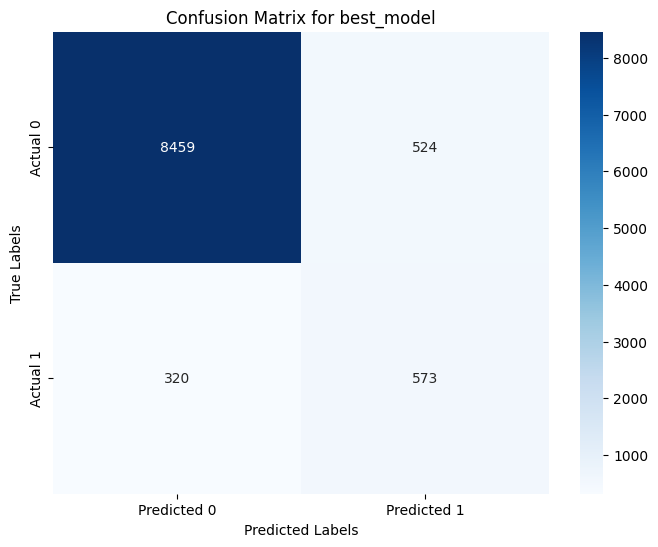


Accuracy: 0.9145


Classification Report for best_model:
              precision    recall  f1-score   support

     Class 0       0.96      0.94      0.95      8983
     Class 1       0.52      0.64      0.58       893

    accuracy                           0.91      9876
   macro avg       0.74      0.79      0.76      9876
weighted avg       0.92      0.91      0.92      9876



In [348]:
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix for best_model")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Evaluate predictions
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}\n")

# Print the classification report
print("\nClassification Report for best_model:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

## Ensemble Model

In [349]:
df_ens = df_dt_ann.copy()
X = df_ens.drop('y', axis=1)
y = df_ens['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

Retrainning the RF model to ANN feature parameter

### New RF

#### RF1 (default)

In [350]:
rf1 = RandomForestClassifier()
rf1.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf1.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9311479559549424
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      7178
           1       0.67      0.49      0.56       723

    accuracy                           0.93      7901
   macro avg       0.81      0.73      0.76      7901
weighted avg       0.92      0.93      0.93      7901



#### RF2 (oversampling)

In [351]:
from imblearn.over_sampling import RandomOverSampler

oversampler = RandomOverSampler(random_state=11,sampling_strategy='minority')
X_resampled, y_resampled = oversampler.fit_resample(X_train, y_train)

from sklearn.ensemble import RandomForestClassifier

# Initialize and train a RandomForestClassifier
rf2 = RandomForestClassifier(n_estimators=100, random_state=11)  # Adjust n_estimators as needed
rf2.fit(X_resampled, y_resampled)

# Make predictions and evaluate the model
y_pred_rf = rf2.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest Classifier: {accuracy_rf}")
print(classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Accuracy of Random Forest Classifier: 0.9234274142513605
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      7178
           1       0.58      0.57      0.58       723

    accuracy                           0.92      7901
   macro avg       0.77      0.77      0.77      7901
weighted avg       0.92      0.92      0.92      7901



#### RF3 (undersampling)

In [352]:
from imblearn.under_sampling import RandomUnderSampler

X_resampled, y_resampled = RandomUnderSampler(random_state=11,sampling_strategy='not minority').fit_resample(X_train, y_train)

# Initialize and train a RandomForestClassifier (or your preferred model)
rf3 = RandomForestClassifier(n_estimators=100, random_state=11)
rf3.fit(X_resampled, y_resampled)

# Make predictions and evaluate the model
y_pred_rf = rf3.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest Classifier (Undersampled): {accuracy_rf}")

print(classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Accuracy of Random Forest Classifier (Undersampled): 0.8571066953550184
              precision    recall  f1-score   support

           0       0.99      0.85      0.92      7178
           1       0.38      0.93      0.54       723

    accuracy                           0.86      7901
   macro avg       0.69      0.89      0.73      7901
weighted avg       0.94      0.86      0.88      7901



#### RF4 (SMOTE)

In [353]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data
smote = SMOTE(random_state=42) # Added random_state for reproducibility
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Initialize and train a RandomForestClassifier
rf4 = RandomForestClassifier(n_estimators=100, random_state=11)
rf4.fit(X_train_resampled, y_train_resampled)

# Make predictions and evaluate the model
y_pred_rf = rf4.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest Classifier (SMOTE): {accuracy_rf}")

print(classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Accuracy of Random Forest Classifier (SMOTE): 0.9202632578154664
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      7178
           1       0.56      0.63      0.59       723

    accuracy                           0.92      7901
   macro avg       0.76      0.79      0.77      7901
weighted avg       0.93      0.92      0.92      7901



#### RF5 (Hypertuned)

In [354]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier with the best hyperparameters
rf5 = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=2,
    max_depth=30,
    random_state=11
    )

# Train the model on the training data
rf5.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf5.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9325401847867358
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      7178
           1       0.69      0.48      0.56       723

    accuracy                           0.93      7901
   macro avg       0.82      0.73      0.76      7901
weighted avg       0.93      0.93      0.93      7901



#### Stacking

In [355]:
# Collect predictions for X_test

rf1_probs = rf1.predict_proba(X_test)[:, 1]  # RF1
rf2_probs = rf2.predict_proba(X_test)[:, 1]  # RF2
rf3_probs = rf3.predict_proba(X_test)[:, 1]  # RF3
rf4_probs = rf4.predict_proba(X_test)[:, 1]  # RF4
rf5_probs = rf5.predict_proba(X_test)[:, 1]  # RF5

ann1_probs = relu1.predict(X_test).flatten()  # ANN1 probabilities
ann2_probs = relu2.predict(X_test).flatten()  # ANN2 probabilities
ann3_probs = relu3.predict(X_test).flatten()  # ANN3 probabilities
ann4_probs = relu4.predict(X_test).flatten()  # ANN4 probabilities

# Stack predictions horizontally to form a new dataset
stacked_predictions = np.column_stack([
    rf1_probs, rf2_probs, rf3_probs, rf4_probs,
    ann1_probs, ann2_probs, ann3_probs, ann4_probs
])

247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [356]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Train the meta-learner
meta_learner = LogisticRegression(random_state=11)
meta_learner.fit(stacked_predictions, y_test)

# Evaluate on the same test data
final_probs = meta_learner.predict_proba(stacked_predictions)[:, 1]
final_preds = (final_probs > 0.5).astype(int)

# Evaluate the performance
roc_auc = roc_auc_score(y_test, final_probs)
print(f"Stacked Model ROC AUC: {roc_auc}")
print(classification_report(y_test, final_preds))


Stacked Model ROC AUC: 0.9517002351198356
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7178
           1       0.64      0.51      0.57       723

    accuracy                           0.93      7901
   macro avg       0.79      0.74      0.76      7901
weighted avg       0.92      0.93      0.92      7901



##### PR curve

In [357]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, final_probs)

# Find the threshold that maximizes F1-score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)  # Avoid division by zero
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (F1-score): {optimal_threshold}")

# Apply the optimal threshold
final_preds1 = (final_probs >= optimal_threshold).astype(int)
final_preds2 = (final_probs >= 0.38).astype(int)

# The performance with the new threshold
roc_auc = roc_auc_score(y_test, final_probs)
print(f"\nStacked Model ROC AUC: {roc_auc}")
print(classification_report(y_test, final_preds1))
print(f"\nStacked Model ROC AUC: {roc_auc}")
print(classification_report(y_test, final_preds2))

Optimal Threshold (F1-score): 0.24749974092799962

Stacked Model ROC AUC: 0.9517002351198356
              precision    recall  f1-score   support

           0       0.98      0.93      0.95      7178
           1       0.52      0.78      0.62       723

    accuracy                           0.91      7901
   macro avg       0.75      0.85      0.79      7901
weighted avg       0.93      0.91      0.92      7901


Stacked Model ROC AUC: 0.9517002351198356
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      7178
           1       0.58      0.63      0.61       723

    accuracy                           0.93      7901
   macro avg       0.77      0.79      0.78      7901
weighted avg       0.93      0.93      0.93      7901



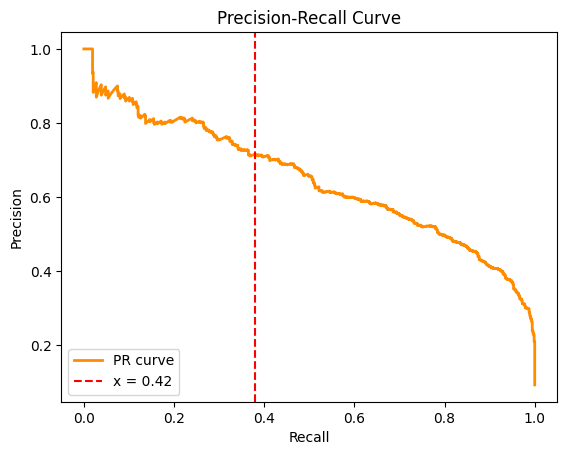

In [358]:
# Plotting PR curve
plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2, label='PR curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.axvline(x=0.38, color='red', linestyle='--', label='x = 0.42') # Added vertical line
plt.legend(loc="lower left")
plt.show()

ROC curve

In [359]:
from sklearn.metrics import roc_curve, roc_auc_score,auc

In [360]:
# Generate FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, final_probs)
# Calculate the distance to the top-left corner
distance = np.sqrt((1 - tpr)**2 + fpr**2)
optimal_idx = np.argmin(distance)  # Index of the optimal threshold
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (ROC): {optimal_threshold}")
# Apply the optimal threshold
final_preds1 = (final_probs >= optimal_threshold).astype(int)
final_preds2 = (final_probs >= 0.2).astype(int)
# Evaluate the performance
roc_auc = roc_auc_score(y_test, final_probs)
print(f"\nStacked Model ROC AUC: {roc_auc}")
print(classification_report(y_test, final_preds1))
# Evaluate the performance
roc_auc = roc_auc_score(y_test, final_probs)
print(f"\nStacked Model ROC AUC: {roc_auc}")
print(classification_report(y_test, final_preds2))

Optimal Threshold (ROC): 0.07584983357928149

Stacked Model ROC AUC: 0.9517002351198356
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7178
           1       0.40      0.93      0.56       723

    accuracy                           0.87      7901
   macro avg       0.70      0.89      0.74      7901
weighted avg       0.94      0.87      0.89      7901


Stacked Model ROC AUC: 0.9517002351198356
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      7178
           1       0.48      0.82      0.61       723

    accuracy                           0.90      7901
   macro avg       0.73      0.86      0.78      7901
weighted avg       0.93      0.90      0.91      7901



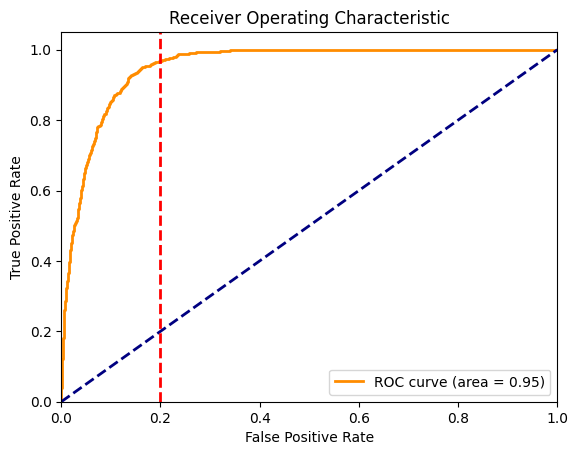

In [361]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, final_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.axvline(x=0.2, color='red', linestyle='--', linewidth=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()